# **Kuramoto model on a network**   
(Kuramoto model on a Watts-Strogatz (WS) Small-World Network)

given a system of N coupled phase oscillators:

θ
i
	​: phase of oscillator i

ω
i
	​
: natural frequency (random Gaussian)

K: coupling strength

A
ij
	: adjacency matrix (network structure)

Each node = oscillator

Each oscillator tries to:
follow its own frequency
but also synchronize with neighbors

Each oscillator i has a natural frequency ωᵢ (drawn from a Gaussian) and a phase θᵢ. The coupling term K·Σ Aᵢⱼ sin(θⱼ - θᵢ) pulls oscillator i toward its connected neighbors. The adjacency matrix A defines the network topology.

When K is small, oscillators spin at their own natural frequencies — incoherent. Above a critical coupling Kc, they spontaneously lock into a collective rhythm — synchronized. The order parameter r(t) = |<e^(iθ)>| measures this: r≈0 means chaos, r≈1 means full sync.

In [3]:
!pip install networkx numpy scipy matplotlib seaborn -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
from scipy.integrate import solve_ivp
import seaborn as sns
from itertools import product

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
np.random.seed(42)

#  Build WS Small-World Network
# Degree-6 ring lattice (3 neighbours each side), then rewire with prob p

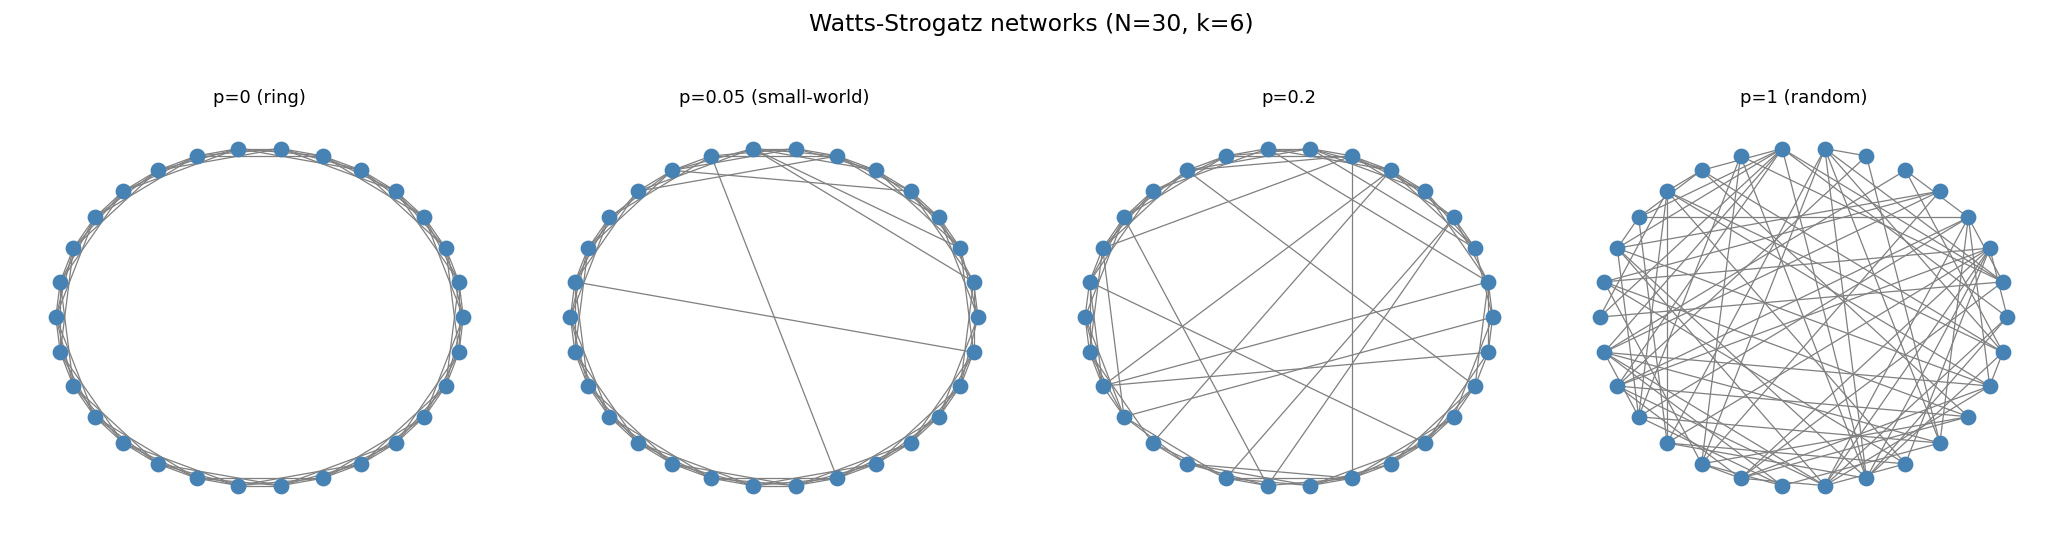

Network visualisation saved.


In [4]:

def build_ws_network(N=100, k=6, p=0.1):
    """
    N : number of nodes
    k : degree of base ring lattice (must be even)
    p : rewiring probability
    Returns networkx graph and its adjacency matrix
    """
    G = nx.watts_strogatz_graph(N, k, p, seed=42)
    A = nx.to_numpy_array(G)
    return G, A

# Visualise the network for a few p values
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
p_vals_vis = [0.0, 0.05, 0.2, 1.0]
labels     = ['p=0 (ring)', 'p=0.05 (small-world)', 'p=0.2', 'p=1 (random)']

for ax, p, lbl in zip(axes, p_vals_vis, labels):
    G, _ = build_ws_network(N=30, k=6, p=p)
    pos  = nx.circular_layout(G)
    nx.draw(G, pos, ax=ax, node_size=60, node_color='steelblue',
            edge_color='gray', width=0.7, with_labels=False)
    ax.set_title(lbl, fontsize=10)

plt.suptitle('Watts-Strogatz networks (N=30, k=6)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('ws_networks.png', bbox_inches='tight')
plt.show()
print("Network visualisation saved.")

***As p increases, the network transitions from a regular lattice to a random graph. Small values of p introduce long-range shortcuts while preserving local clustering***

# Block 3: Network structural properties vs rewiring probability p
# This is the iconic Watts-Strogatz small-world result

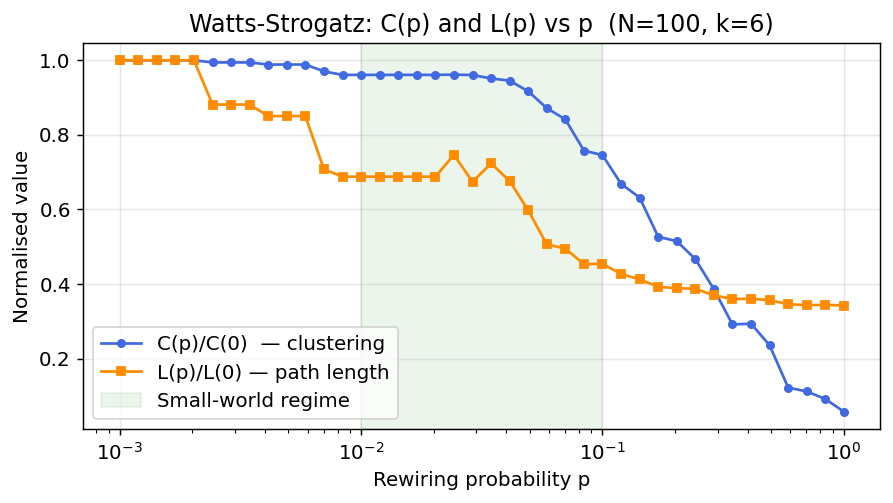

In [5]:

N, k  = 100, 6
p_arr = np.logspace(-3, 0, 40)   # log-spaced from 0.001 to 1

C_arr = []   # clustering coefficient (normalised)
L_arr = []   # average path length (normalised)

for p in p_arr:
    G, _ = build_ws_network(N=N, k=k, p=p)
    C_arr.append(nx.average_clustering(G))
    # Only compute path length for connected graphs
    if nx.is_connected(G):
        L_arr.append(nx.average_shortest_path_length(G))
    else:
        # Use largest connected component
        Gc = G.subgraph(max(nx.connected_components(G), key=len))
        L_arr.append(nx.average_shortest_path_length(Gc))

C_arr = np.array(C_arr)
L_arr = np.array(L_arr)

# Normalise by p=0 (ring) values
C0 = C_arr[0]
L0 = L_arr[0]

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(p_arr, C_arr/C0, 'o-', color='royalblue',  ms=4, lw=1.5, label='C(p)/C(0)  — clustering')
ax.semilogx(p_arr, L_arr/L0, 's-', color='darkorange', ms=4, lw=1.5, label='L(p)/L(0) — path length')
ax.axvspan(0.01, 0.1, alpha=0.08, color='green', label='Small-world regime')
ax.set_xlabel('Rewiring probability p')
ax.set_ylabel('Normalised value')
ax.set_title('Watts-Strogatz: C(p) and L(p) vs p  (N=100, k=6)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ws_properties.png', bbox_inches='tight')
plt.show()

***A small increase in rewiring probability leads to a rapid decrease in mean path length while clustering remains high. This defines the small-world regime.***

# Block 4: Core Kuramoto ODE integrator


Kuramoto simulator defined.


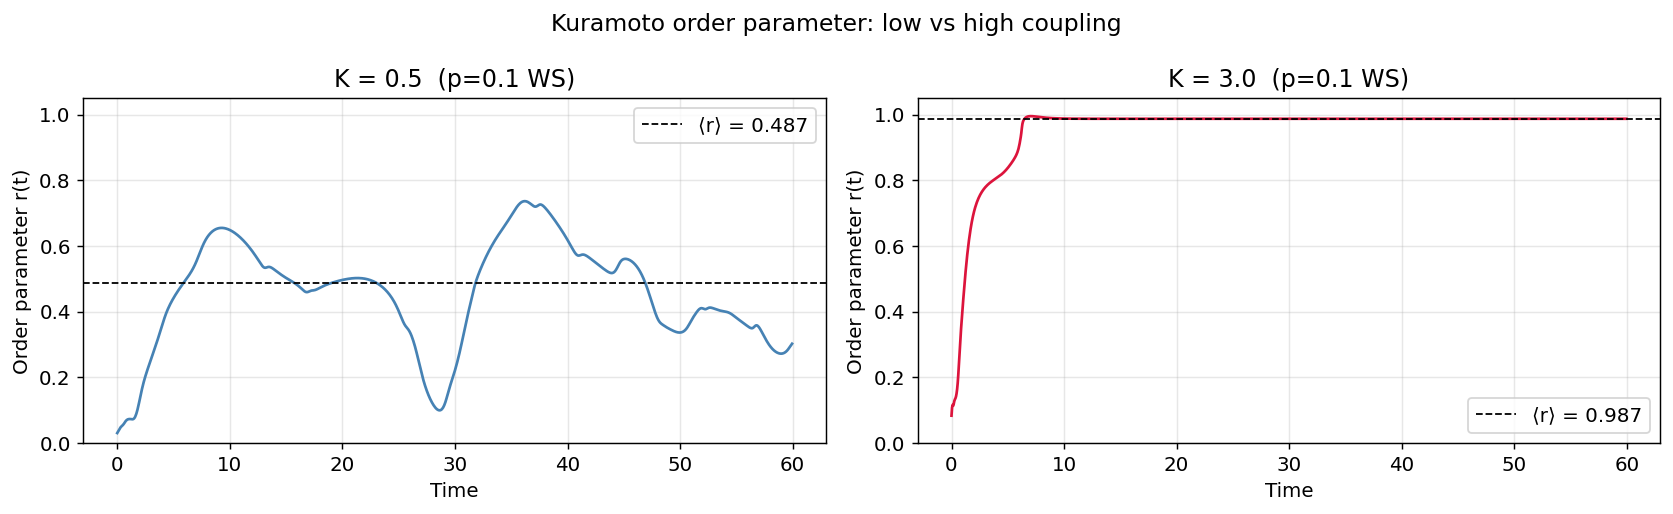

In [6]:

def kuramoto_ode(t, theta, omega, K, A):
    """
    dθᵢ/dt = ωᵢ + K * Σⱼ Aᵢⱼ sin(θⱼ - θᵢ)
    """
    N       = len(theta)
    dtheta  = omega.copy()
    # Vectorised coupling term
    diff    = theta[np.newaxis, :] - theta[:, np.newaxis]   # (N,N)
    dtheta += K * np.sum(A * np.sin(diff), axis=1)
    return dtheta

def order_parameter(theta):
    """
    r = |<e^{iθ}>|  (Kuramoto order parameter, 0=incoherent, 1=sync)
    """
    return np.abs(np.mean(np.exp(1j * theta)))

def simulate_kuramoto(N, A, omega, K, T=50, dt=0.05):
    """
    Integrate Kuramoto model.
    Returns time array and order parameter trajectory r(t).
    """
    theta0  = np.random.uniform(0, 2*np.pi, N)
    t_span  = (0, T)
    t_eval  = np.arange(0, T, dt)

    sol = solve_ivp(
        fun      = lambda t, y: kuramoto_ode(t, y, omega, K, A),
        t_span   = t_span,
        y0       = theta0,
        t_eval   = t_eval,
        method   = 'RK45',
        rtol     = 1e-6,
        atol     = 1e-8
    )

    r_t = np.array([order_parameter(sol.y[:, i]) for i in range(sol.y.shape[1])])
    return sol.t, r_t, sol.y

print("Kuramoto simulator defined.")

# --- Quick test: single run ---
N     = 100
p     = 0.1
G, A  = build_ws_network(N=N, k=6, p=p)
omega = np.random.randn(N)          # Gaussian N(0,1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, K, col in zip(axes, [0.5, 3.0], ['steelblue', 'crimson']):
    t, r_t, theta_t = simulate_kuramoto(N, A, omega, K, T=60)
    ax.plot(t, r_t, color=col, lw=1.5)
    ax.axhline(np.mean(r_t[len(r_t)//2:]), color='k', ls='--', lw=1,
               label=f'⟨r⟩ = {np.mean(r_t[len(r_t)//2:]):.3f}')
    ax.set_xlabel('Time')
    ax.set_ylabel('Order parameter r(t)')
    ax.set_title(f'K = {K}  (p=0.1 WS)')
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Kuramoto order parameter: low vs high coupling', fontsize=13)
plt.tight_layout()
plt.savefig('r_vs_time_sample.png', bbox_inches='tight')
plt.show()

**For small K → weak synchronization**

**For large K → strong synchronization**


# Block 5: Sweep K → find synchronization phase transition & critical coupling Kc

  K=5.00  r=0.956
Estimated Kc ≈ 0.64


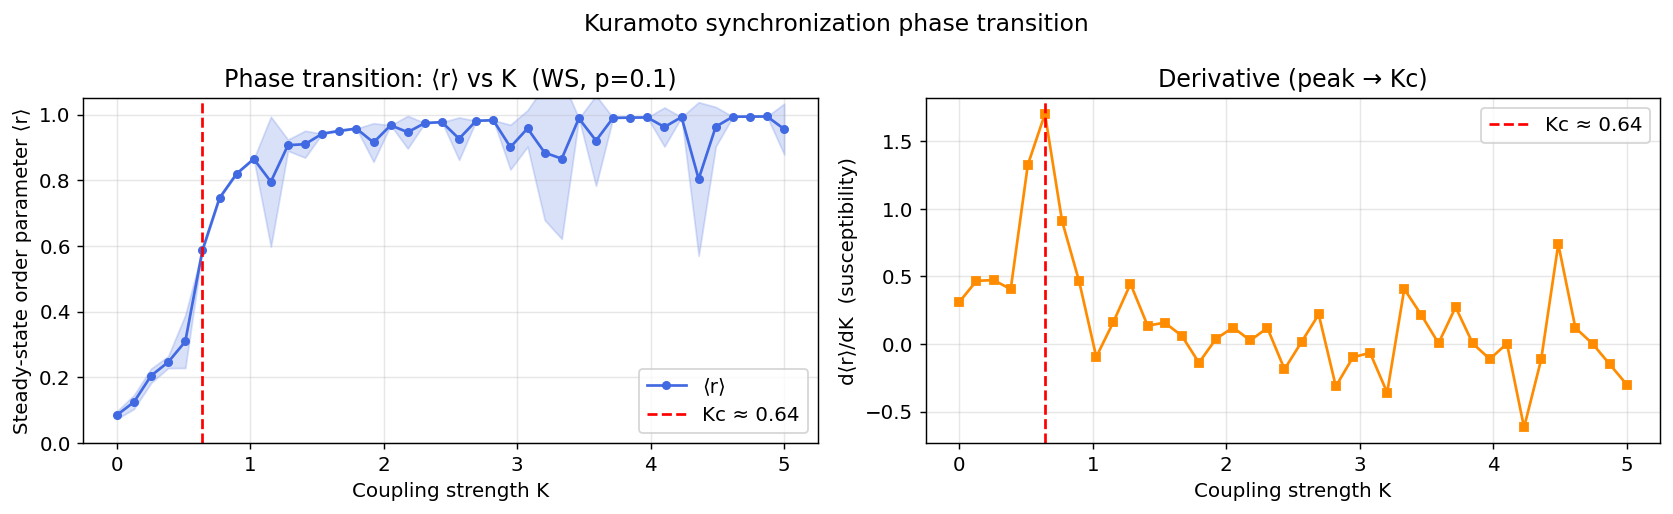

In [7]:

N       = 100
p       = 0.1
G, A    = build_ws_network(N=N, k=6, p=p)
omega   = np.random.randn(N)

K_arr   = np.linspace(0.0, 5.0, 40)
n_runs  = 5      # average over multiple random initial conditions
T_sim   = 80
t_ss    = 40     # use second half as steady-state

r_mean  = []
r_std   = []

for K in K_arr:
    r_runs = []
    for _ in range(n_runs):
        t, r_t, _ = simulate_kuramoto(N, A, omega, K, T=T_sim)
        ss_mask   = t >= t_ss
        r_runs.append(np.mean(r_t[ss_mask]))
    r_mean.append(np.mean(r_runs))
    r_std.append(np.std(r_runs))
    print(f"  K={K:.2f}  r={r_mean[-1]:.3f}", end='\r')

r_mean = np.array(r_mean)
r_std  = np.array(r_std)

# Estimate Kc as point of maximum dr/dK
dr_dK  = np.gradient(r_mean, K_arr)
Kc_est = K_arr[np.argmax(dr_dK)]
print(f"\nEstimated Kc ≈ {Kc_est:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(K_arr, r_mean, 'o-', color='royalblue', ms=4, lw=1.5, label='⟨r⟩')
ax.fill_between(K_arr, r_mean - r_std, r_mean + r_std, alpha=0.2, color='royalblue')
ax.axvline(Kc_est, color='red', ls='--', lw=1.5, label=f'Kc ≈ {Kc_est:.2f}')
ax.set_xlabel('Coupling strength K')
ax.set_ylabel('Steady-state order parameter ⟨r⟩')
ax.set_title('Phase transition: ⟨r⟩ vs K  (WS, p=0.1)')
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(K_arr, dr_dK, 's-', color='darkorange', ms=4, lw=1.5)
ax.axvline(Kc_est, color='red', ls='--', lw=1.5, label=f'Kc ≈ {Kc_est:.2f}')
ax.set_xlabel('Coupling strength K')
ax.set_ylabel('d⟨r⟩/dK  (susceptibility)')
ax.set_title('Derivative (peak → Kc)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Kuramoto synchronization phase transition', fontsize=13)
plt.tight_layout()
plt.savefig('phase_transition.png', bbox_inches='tight')
plt.show()

 **“The order parameter ⟨r⟩ increases gradually with coupling strength K, but shows a rapid rise near a critical value
K
c≈0.64, indicating a synchronization phase transition.”**


**“The peak in d⟨r⟩/dK identifies the critical coupling strength where the system transitions from incoherent to synchronized behavior.”**




curve is slightly noisy at higher K.
Reason:
finite N
randomness in ω

# Block 6: How does rewiring probability p affect synchronization?
# Core small-world result: even small p dramatically lowers Kc

  Done p=0.0
  Done p=0.01
  Done p=0.05
  Done p=0.1
  Done p=0.3
  Done p=1.0


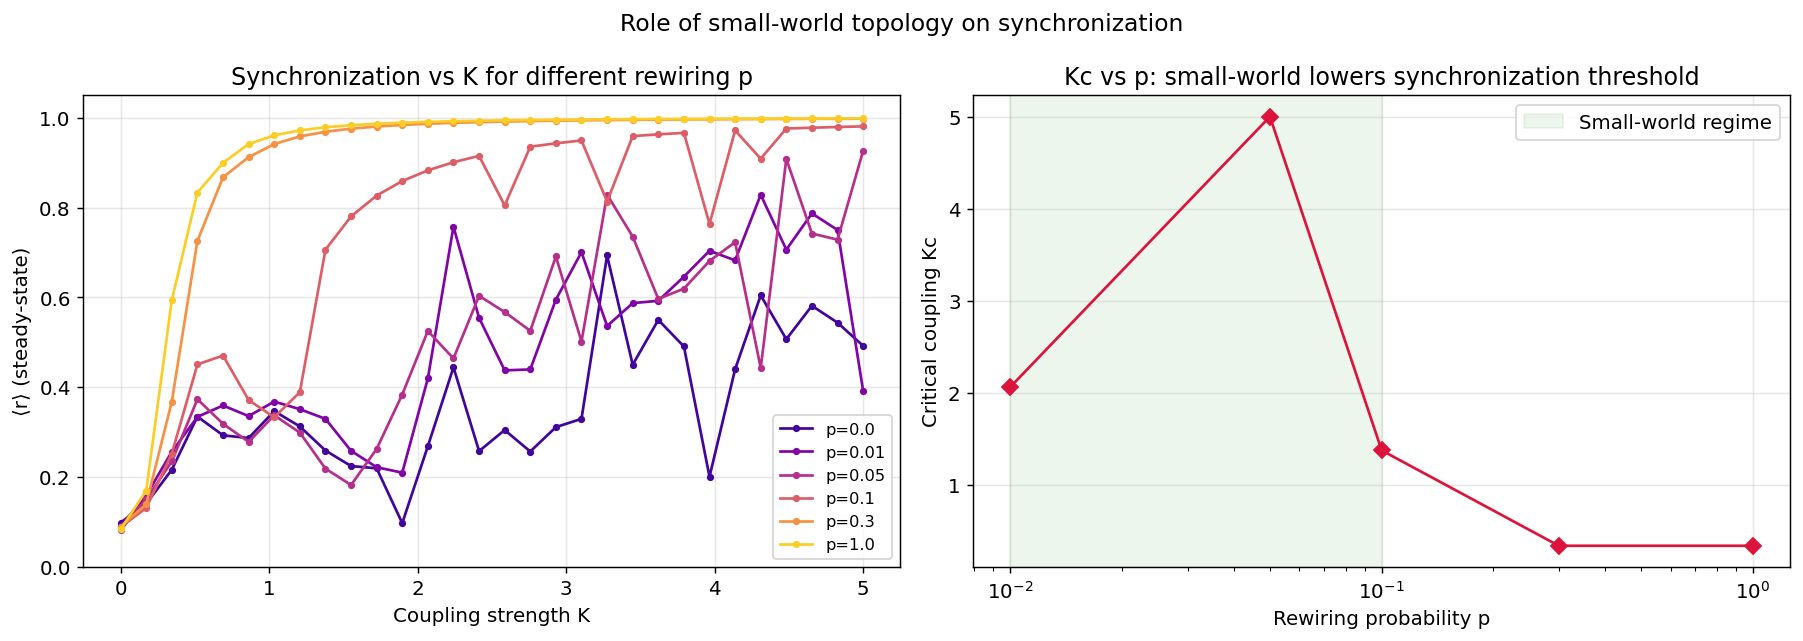

In [11]:
N       = 100
omega   = np.random.randn(N)
K_arr   = np.linspace(0, 5, 30)
p_vals  = [0.0, 0.01, 0.05, 0.1, 0.3, 1.0]
n_runs  = 3
T_sim   = 80
t_ss    = 40

results = {}   # p → array of r_mean over K

for p in p_vals:
    G, A  = build_ws_network(N=N, k=6, p=p)
    r_arr = []
    for K in K_arr:
        rr = []
        for _ in range(n_runs):
            t, r_t, _ = simulate_kuramoto(N, A, omega, K, T=T_sim)
            rr.append(np.mean(r_t[t >= t_ss]))
        r_arr.append(np.mean(rr))
    results[p] = np.array(r_arr)
    print(f"  Done p={p}")

# Estimate Kc per p
Kc_per_p = {}
for p, r_arr in results.items():
    dr = np.gradient(r_arr, K_arr)
    Kc_per_p[p] = K_arr[np.argmax(dr)]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(p_vals)))

ax = axes[0]
for (p, r_arr), col in zip(results.items(), colors):
    ax.plot(K_arr, r_arr, 'o-', color=col, ms=3, lw=1.5, label=f'p={p}')
ax.set_xlabel('Coupling strength K')
ax.set_ylabel('⟨r⟩ (steady-state)')
ax.set_title('Synchronization vs K for different rewiring p')
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogx(list(Kc_per_p.keys())[1:],   # skip p=0 (ring) for log-scale
            list(Kc_per_p.values())[1:],
            'D-', color='crimson', ms=6, lw=1.5)
ax.set_xlabel('Rewiring probability p')
ax.set_ylabel('Critical coupling Kc')
ax.set_title('Kc vs p: small-world lowers synchronization threshold')
ax.grid(True, alpha=0.3)
ax.axvspan(0.01, 0.1, alpha=0.07, color='green', label='Small-world regime')
ax.legend()

plt.suptitle('Role of small-world topology on synchronization', fontsize=13)
plt.tight_layout()
plt.savefig('sync_vs_rewiring.png', bbox_inches='tight')
plt.show()

**The critical coupling strength decreases as rewiring probability increases, indicating that small-world and random networks synchronize more easily than regular lattices.**

**The presence of shortcuts reduces path length, enabling faster information flow and lowering synchronization threshold.**

# Block 7: Full 2D parameter sweep — heatmap of ⟨r⟩ over K × p grid

  p=0.010 done
  p=0.014 done
  p=0.019 done
  p=0.027 done
  p=0.037 done
  p=0.052 done
  p=0.072 done
  p=0.100 done
  p=0.139 done
  p=0.193 done
  p=0.268 done
  p=0.373 done
  p=0.518 done
  p=0.720 done
  p=1.000 done


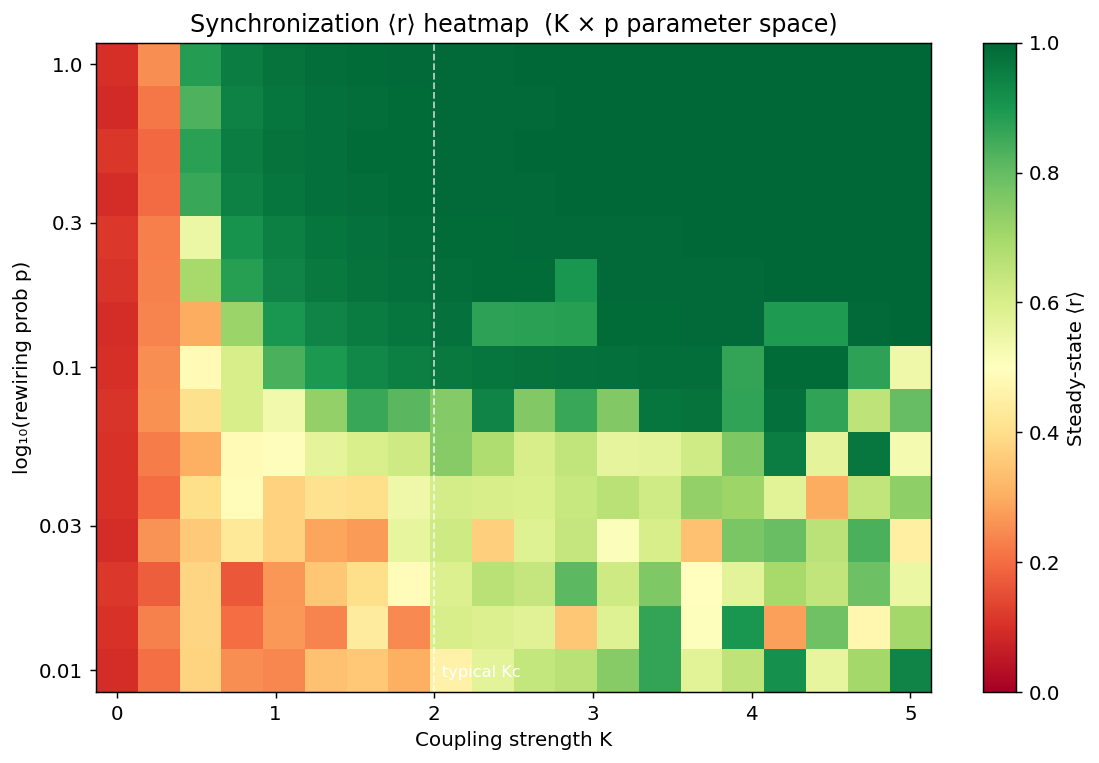

In [12]:
N       = 80    # smaller N for speed
omega   = np.random.randn(N)
K_grid  = np.linspace(0, 5, 20)
p_grid  = np.logspace(-2, 0, 15)   # 0.01 → 1.0
n_runs  = 2
T_sim   = 60
t_ss    = 30

r_matrix = np.zeros((len(p_grid), len(K_grid)))

for i, p in enumerate(p_grid):
    G, A = build_ws_network(N=N, k=6, p=p)
    for j, K in enumerate(K_grid):
        rr = []
        for _ in range(n_runs):
            t, r_t, _ = simulate_kuramoto(N, A, omega, K, T=T_sim)
            rr.append(np.mean(r_t[t >= t_ss]))
        r_matrix[i, j] = np.mean(rr)
    print(f"  p={p:.3f} done")

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.pcolormesh(K_grid, np.log10(p_grid), r_matrix,
                   cmap='RdYlGn', vmin=0, vmax=1, shading='auto')
plt.colorbar(im, ax=ax, label='Steady-state ⟨r⟩')
ax.set_xlabel('Coupling strength K')
ax.set_ylabel('log₁₀(rewiring prob p)')
ax.set_title('Synchronization ⟨r⟩ heatmap  (K × p parameter space)')
ax.axvline(2.0, color='white', ls='--', lw=1, alpha=0.7)
ax.text(2.05, ax.get_ylim()[0]+0.05, 'typical Kc', color='white', fontsize=9)

yticks = np.log10([0.01, 0.03, 0.1, 0.3, 1.0])
ax.set_yticks(yticks)
ax.set_yticklabels(['0.01', '0.03', '0.1', '0.3', '1.0'])

plt.tight_layout()
plt.savefig('r_heatmap_K_p.png', bbox_inches='tight')
plt.show()

**The heatmap shows that synchronization increases with both coupling strength K and rewiring probability p.”**

 **“For low p (regular lattice), higher coupling is required to achieve synchronization, whereas for higher p (small-world and random networks), synchronization occurs at lower coupling.”**

 **“This demonstrates that small-world topology enhances synchronization efficiency by reducing the required coupling strength.”**

# Block 8: Visualise phase coherence snapshots at different K values

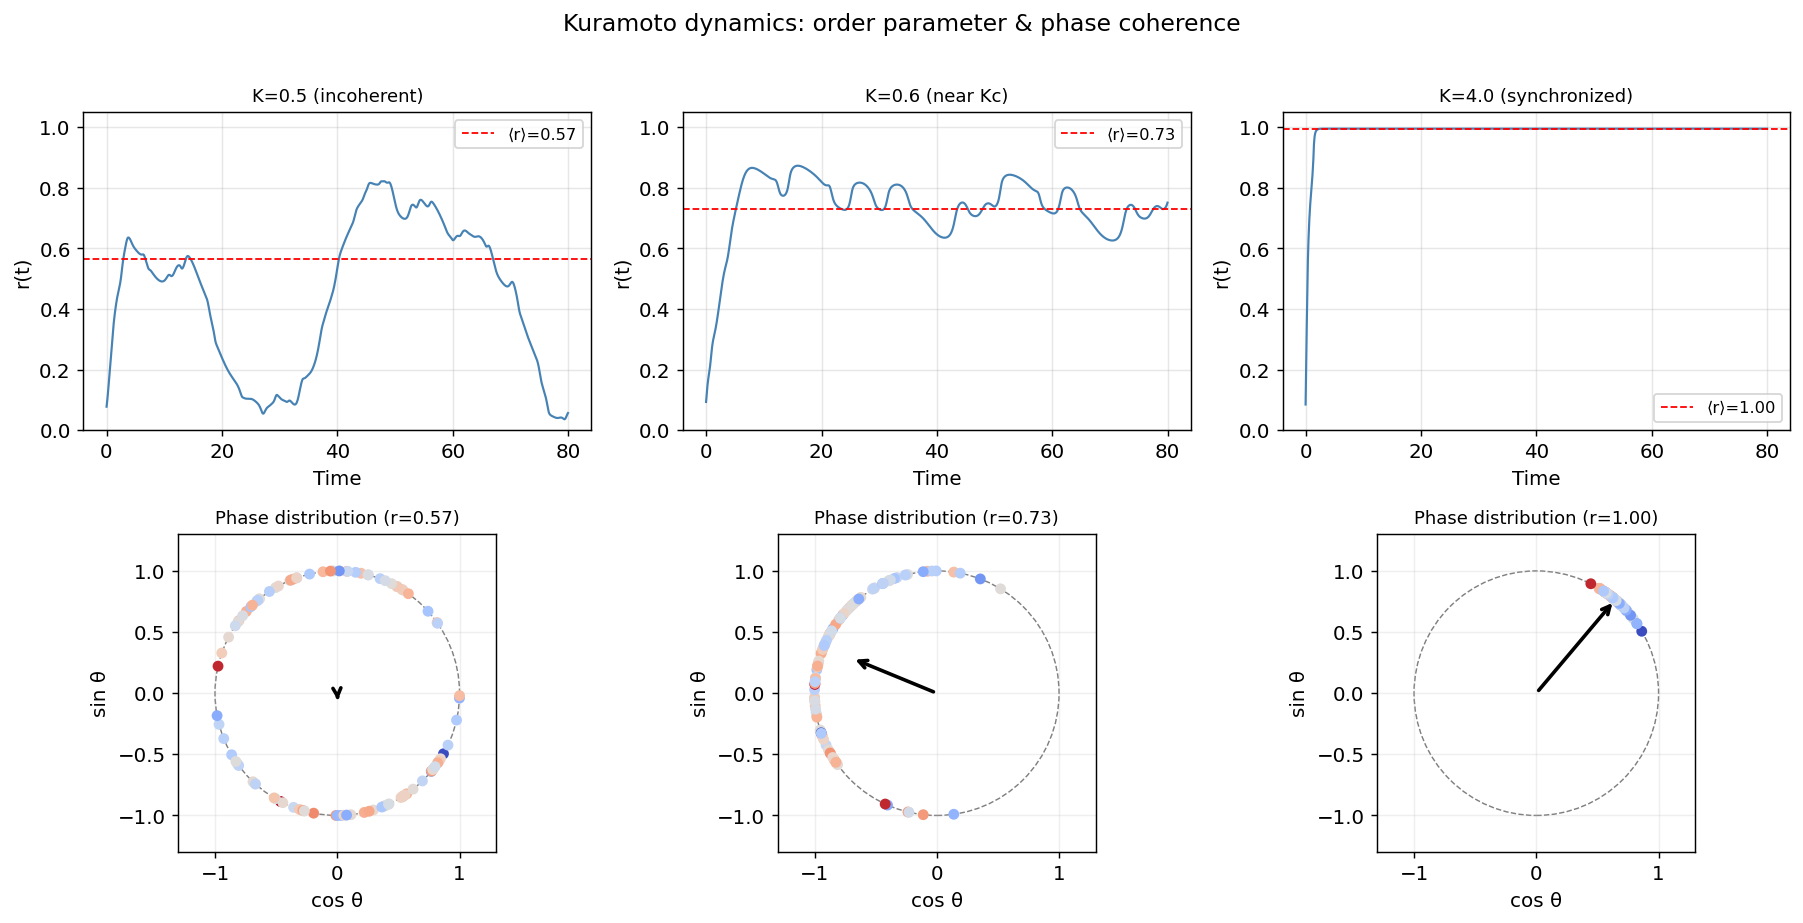

In [13]:

N     = 100
p     = 0.1
G, A  = build_ws_network(N=N, k=6, p=p)
omega = np.random.randn(N)

K_cases = [0.5, Kc_est, 4.0]
labels  = [f'K={k} (incoherent)' if k < Kc_est
           else (f'K={k:.1f} (near Kc)' if abs(k - Kc_est) < 0.5
                 else f'K={k} (synchronized)')
           for k in K_cases]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

for col, (K, lbl) in enumerate(zip(K_cases, labels)):
    t, r_t, theta_t = simulate_kuramoto(N, A, omega, K, T=80)

    # Top row: r(t) time series
    ax = axes[0, col]
    ax.plot(t, r_t, lw=1.2, color='steelblue')
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Time')
    ax.set_ylabel('r(t)')
    ax.set_title(lbl, fontsize=10)
    r_ss = np.mean(r_t[t >= 40])
    ax.axhline(r_ss, color='red', ls='--', lw=1, label=f'⟨r⟩={r_ss:.2f}')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # Bottom row: phase scatter on unit circle at t_final
    ax = axes[1, col]
    theta_final = theta_t[:, -1]
    x, y = np.cos(theta_final), np.sin(theta_final)
    ax.scatter(x, y, c=omega, cmap='coolwarm', s=25, zorder=3)
    # draw mean resultant vector
    rx = np.mean(x); ry = np.mean(y)
    ax.annotate('', xy=(rx, ry), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
    circle = plt.Circle((0, 0), 1, fill=False, color='gray', lw=0.8, ls='--')
    ax.add_patch(circle)
    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal')
    ax.set_title(f'Phase distribution (r={r_ss:.2f})', fontsize=10)
    ax.set_xlabel('cos θ'); ax.set_ylabel('sin θ')
    ax.grid(True, alpha=0.2)

plt.suptitle('Kuramoto dynamics: order parameter & phase coherence', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('phase_snapshots.png', bbox_inches='tight')
plt.show()

**At low coupling, oscillator phases are uniformly distributed, resulting in low synchronization.”**

**“Near the critical coupling, partial phase clustering emerges, indicating the onset of synchronization.”**

**“At high coupling, all oscillators align in phase, forming a coherent cluster and achieving full synchronization.”**

# Block 9: Instantaneous frequency ωᵢ_eff(t) = dθᵢ/dt
# Synchronized oscillators should have the same effective frequency

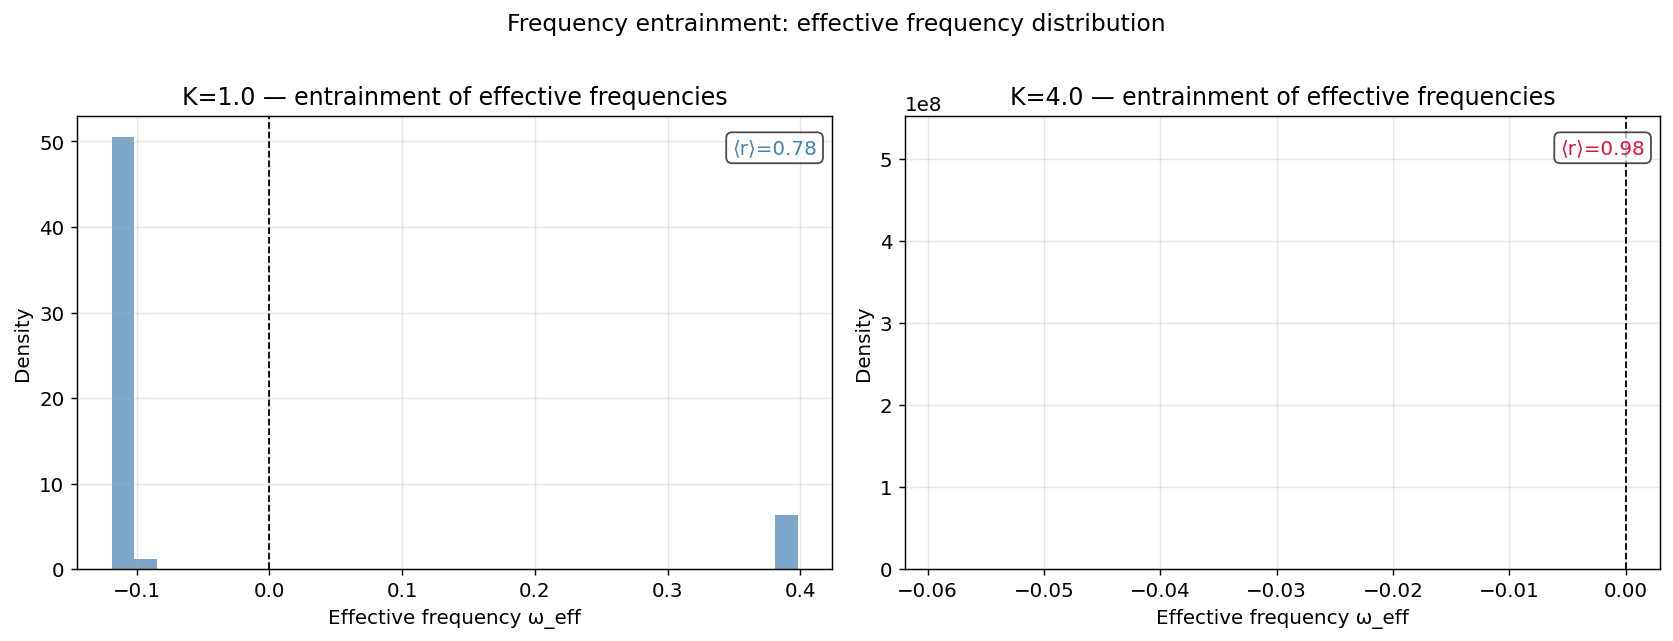

In [26]:
N     = 100
p     = 0.1
G, A  = build_ws_network(N=N, k=6, p=p)
omega = np.random.randn(N)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, K, col in zip(axes, [1.0, 4.0], ['steelblue', 'crimson']):
    t, r_t, theta_t = simulate_kuramoto(N, A, omega, K, T=80, dt=0.05)

    # Compute instantaneous frequency dθᵢ/dt numerically
    inst_freq = np.gradient(np.unwrap(theta_t, axis=1), t, axis=1)
    # Time-averaged effective frequency (second half)
    ss_mask   = t >= 40
    omega_eff = np.mean(inst_freq[:, ss_mask], axis=1)

    ax.hist(omega_eff, bins=30, color=col, alpha=0.7, density=True)
    ax.axvline(0, color='k', ls='--', lw=1)
    ax.set_xlabel('Effective frequency ω_eff')
    ax.set_ylabel('Density')
    ax.set_title(f'K={K} — entrainment of effective frequencies')
    ax.grid(True, alpha=0.3)
    r_ss = np.mean(r_t[t >= 40])
    ax.text(0.98, 0.95, f'⟨r⟩={r_ss:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=11, color=col,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.suptitle('Frequency entrainment: effective frequency distribution', fontsize=13)
plt.tight_layout()
plt.savefig('freq_entrainment.png', bbox_inches='tight')
plt.show()

**As coupling increases, oscillators not only synchronize in phase but also align their effective frequencies.”**

**“At high coupling, the frequency distribution collapses, indicating complete frequency entrainment.”**

# Block 10: Summary

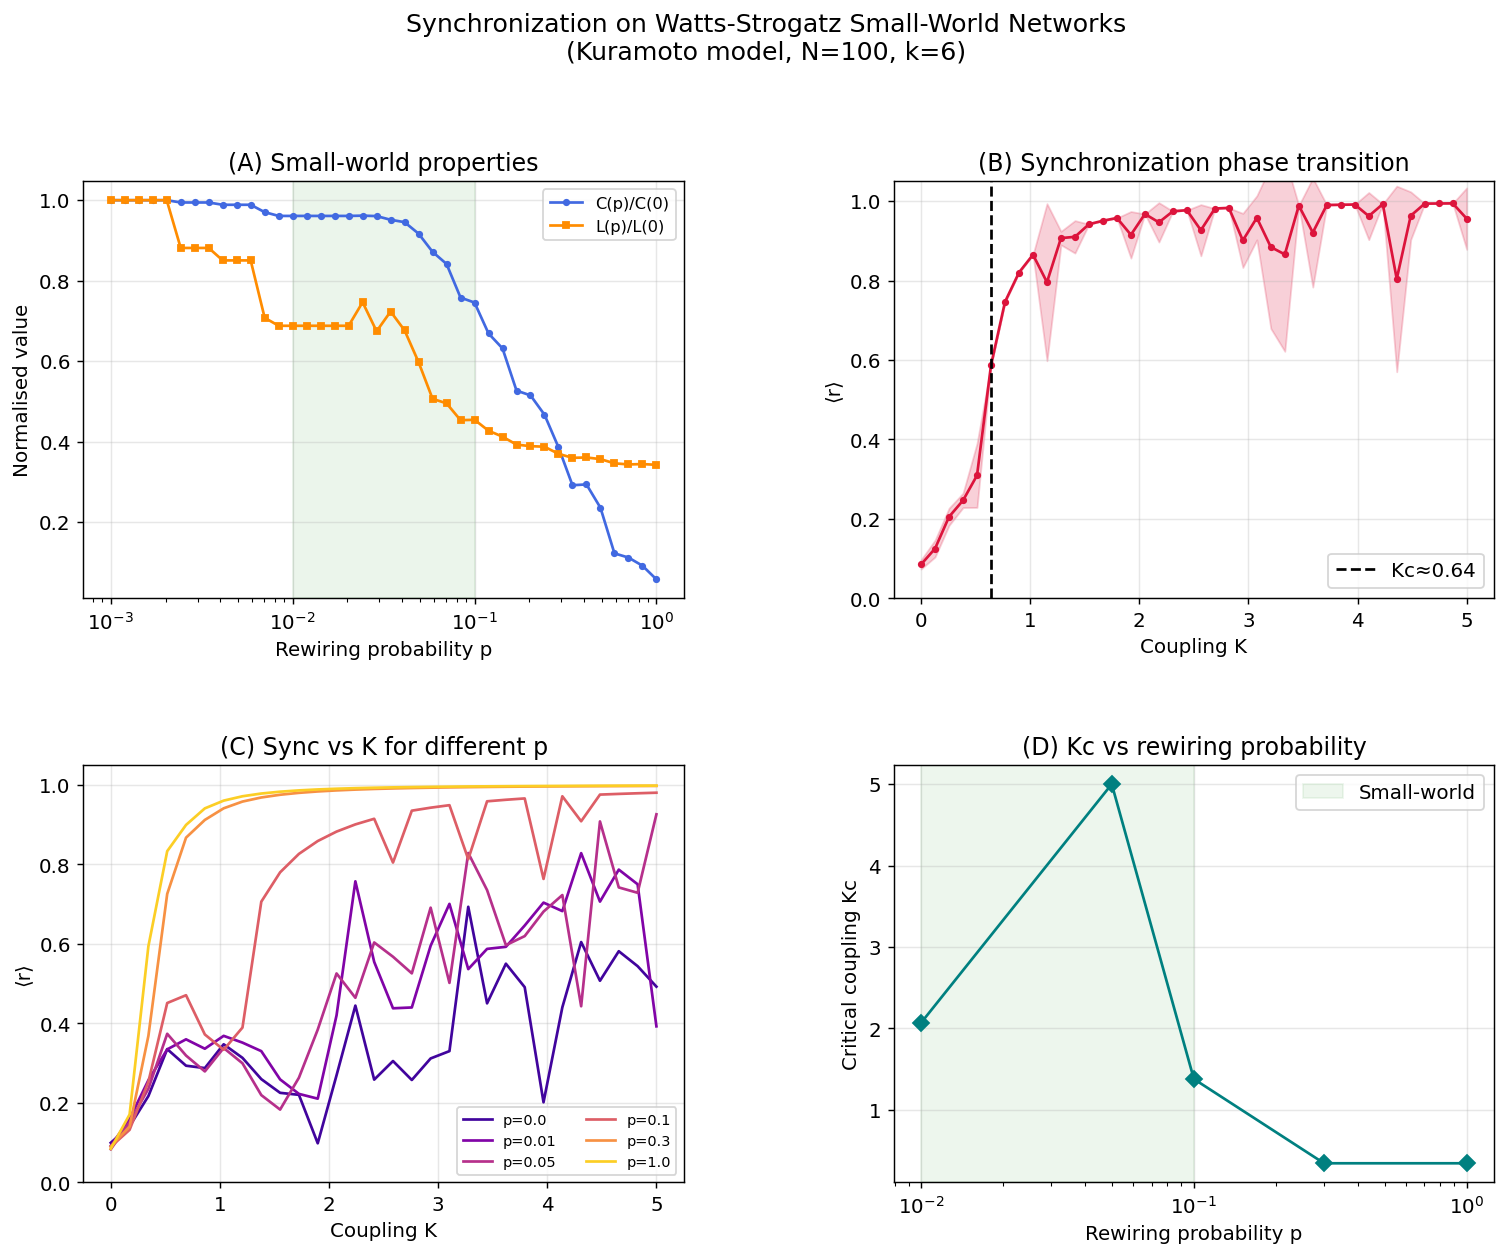

All plots saved.


In [22]:
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# Panel A: C(p)/C(0) and L(p)/L(0) — from Block 3
ax_A = fig.add_subplot(gs[0, 0])
ax_A.semilogx(p_arr, C_arr/C0, 'o-', color='royalblue',  ms=3, lw=1.5, label='C(p)/C(0)')
ax_A.semilogx(p_arr, L_arr/L0, 's-', color='darkorange', ms=3, lw=1.5, label='L(p)/L(0)')
ax_A.axvspan(0.01, 0.1, alpha=0.08, color='green')
ax_A.set_xlabel('Rewiring probability p')
ax_A.set_ylabel('Normalised value')
ax_A.set_title('(A) Small-world properties')
ax_A.legend(fontsize=9); ax_A.grid(True, alpha=0.3)

# Panel B: Phase transition r vs K — from Block 5
ax_B = fig.add_subplot(gs[0, 1])
# Recreate the K_arr used for r_mean and r_std calculation in Block 5
K_arr_block5 = np.linspace(0.0, 5.0, 40)
ax_B.plot(K_arr_block5, r_mean, 'o-', color='crimson', ms=3, lw=1.5)
ax_B.fill_between(K_arr_block5, r_mean - r_std, r_mean + r_std, alpha=0.2, color='crimson')
ax_B.axvline(Kc_est, color='k', ls='--', lw=1.5, label=f'Kc≈{Kc_est:.2f}')
ax_B.set_xlabel('Coupling K'); ax_B.set_ylabel('⟨r⟩')
ax_B.set_title('(B) Synchronization phase transition')
ax_B.set_ylim(0, 1.05); ax_B.legend(); ax_B.grid(True, alpha=0.3)

# Panel C: r vs K for multiple p — from Block 6
ax_C = fig.add_subplot(gs[1, 0])
for (p, r_arr), col in zip(results.items(), colors):
    ax_C.plot(K_arr, r_arr, '-', color=col, lw=1.5, label=f'p={p}')
ax_C.set_xlabel('Coupling K'); ax_C.set_ylabel('⟨r⟩')
ax_C.set_title('(C) Sync vs K for different p')
ax_C.set_ylim(0, 1.05); ax_C.legend(fontsize=8, ncol=2); ax_C.grid(True, alpha=0.3)

# Panel D: Kc vs p
ax_D = fig.add_subplot(gs[1, 1])
ps   = list(Kc_per_p.keys())[1:]
kcs  = list(Kc_per_p.values())[1:]
ax_D.semilogx(ps, kcs, 'D-', color='teal', ms=6, lw=1.5)
ax_D.set_xlabel('Rewiring probability p')
ax_D.set_ylabel('Critical coupling Kc')
ax_D.set_title('(D) Kc vs rewiring probability')
ax_D.axvspan(0.01, 0.1, alpha=0.07, color='green', label='Small-world')
ax_D.legend(); ax_D.grid(True, alpha=0.3)

plt.suptitle('Synchronization on Watts-Strogatz Small-World Networks\n(Kuramoto model, N=100, k=6)',
             fontsize=14, y=1.01)
plt.savefig('summary_figure.png', bbox_inches='tight', dpi=150)
plt.show()
print("All plots saved.")

In this study, I investigated synchronization of coupled phase oscillators on Watts–Strogatz small-world networks using the Kuramoto model. The network structure was characterized using clustering coefficient and mean path length, confirming the existence of a small-world regime with high clustering and low path length.

The system exhibits a synchronization phase transition at a critical coupling K
c
	​

, beyond which oscillators become phase-locked. Importantly, the network topology strongly influences this transition. As the rewiring probability p increases, long-range connections reduce path length and facilitate faster information transfer across the network.

Consequently, small-world and random networks require lower coupling strength to achieve synchronization compared to regular lattice networks. This demonstrates that small-world topology enhances synchronization efficiency.

At high coupling strengths, the system achieves complete phase synchronization, and oscillators also exhibit frequency entrainment, indicating coherent collective dynamics.